In [1]:
import pandas as pd

df_ai = pd.read_csv("chatgpt-reddit-comments.csv")
df_decisions = pd.read_csv("kaggle_RC_2019-05.csv")

print("AI dataset columns:", df_ai.columns.tolist())
print("Decisions dataset columns:", df_decisions.columns.tolist())

AI dataset columns: ['Unnamed: 0', 'comment_id', 'comment_parent_id', 'comment_body', 'subreddit']
Decisions dataset columns: ['subreddit', 'body', 'controversiality', 'score']


In [2]:
# Rename columns so both datasets match
df_ai = df_ai.rename(columns={"comment_body": "text"})
df_decisions = df_decisions.rename(columns={"body": "text"})

# Label which era each dataset represents
df_ai["era"] = "post_llm"
df_decisions["era"] = "pre_llm"

# Keep only the columns we need
df_ai = df_ai[["text", "subreddit", "era"]]
df_decisions = df_decisions[["text", "subreddit", "era"]]

# Combine them into one dataframe
df = pd.concat([df_ai, df_decisions], ignore_index=True)

# Check it worked
print(df.shape)
print(df["era"].value_counts())
df.head()

(1052416, 3)
era
pre_llm     1000000
post_llm      52416
Name: count, dtype: int64


,text,subreddit,era
0,"I've been shocked for days now, I don't need c...",r/ChatGPT,post_llm
1,\n\nI am so angry right now. I just wasted my...,r/ChatGPT,post_llm
2,chatgpt karma whoring is here folks! just when...,r/ChatGPT,post_llm
3,"Worked on me, ngl.",r/ChatGPT,post_llm
4,"Certified 10/10, must-see moment. It really di...",r/ChatGPT,post_llm


In [3]:
# Sample 50,000 from each era so the comparison is balanced
df_pre = df[df["era"] == "pre_llm"].sample(50000, random_state=42)
df_post = df[df["era"] == "post_llm"].sample(50000, random_state=42)

# Combine the balanced dataset
df_balanced = pd.concat([df_pre, df_post], ignore_index=True)

# Drop any empty/null text rows
df_balanced = df_balanced.dropna(subset=["text"])

print(df_balanced.shape)
print(df_balanced["era"].value_counts())

(99999, 3)
era
pre_llm     50000
post_llm    49999
Name: count, dtype: int64


In [5]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Set up the analyzer
analyzer = SentimentIntensityAnalyzer()

# Run sentiment on every comment (this may take a minute)
df_balanced["sentiment"] = df_balanced["text"].apply(
    lambda x: analyzer.polarity_scores(str(x))["compound"]
)

# Preview the results
print(df_balanced[["text", "era", "sentiment"]].head(10))

                                                text      era  sentiment
0  How ironic that you're being indignant on the ...  pre_llm    -0.9175
1  I started work in 99 when the boomers we're st...  pre_llm    -0.8271
2  Any combination of the following:\n\nAAE Pump ...  pre_llm    -0.9853
3  Compare pharma's marketing budget to it's R&am...  pre_llm    -0.7814
4                Wasn't it an illegitimate election?  pre_llm     0.0000
5  Oh I noticed and it was truly epic\n\nThanos i...  pre_llm    -0.0508
6  He was amazing, so funny, had a future.... in ...  pre_llm     0.8196
7  Two do, and they can’t escape the muscle mass ...  pre_llm    -0.0772
8  With a CC you need to verify the signature.......  pre_llm     0.4877
9  I've never seen any of them either, and I also...  pre_llm     0.0000


Matplotlib is building the font cache; this may take a moment.


era
post_llm    0.167436
pre_llm     0.078238
Name: sentiment, dtype: float64


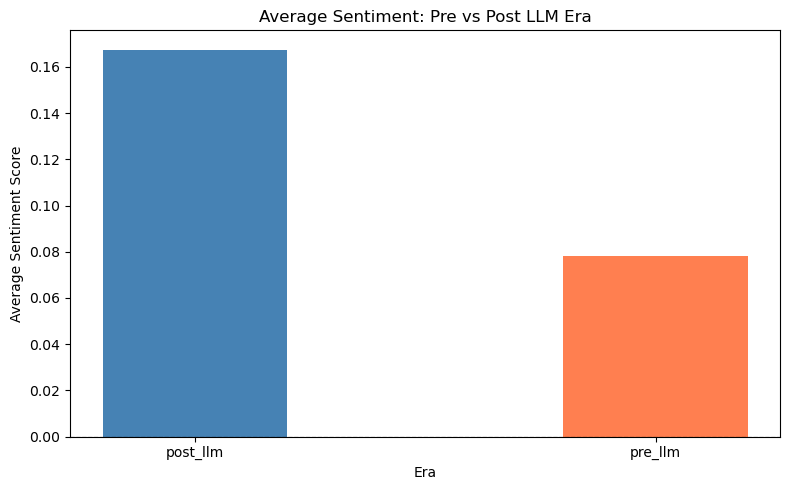

In [6]:
import matplotlib.pyplot as plt

# Calculate average sentiment by era
sentiment_by_era = df_balanced.groupby("era")["sentiment"].mean()
print(sentiment_by_era)

# Plot it
plt.figure(figsize=(8, 5))
plt.bar(sentiment_by_era.index, sentiment_by_era.values, 
        color=["steelblue", "coral"], width=0.4)
plt.title("Average Sentiment: Pre vs Post LLM Era")
plt.xlabel("Era")
plt.ylabel("Average Sentiment Score")
plt.axhline(y=0, color="black", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.show()

era
post_llm    0.043301
pre_llm     0.021180
Name: uncertainty_score, dtype: float64


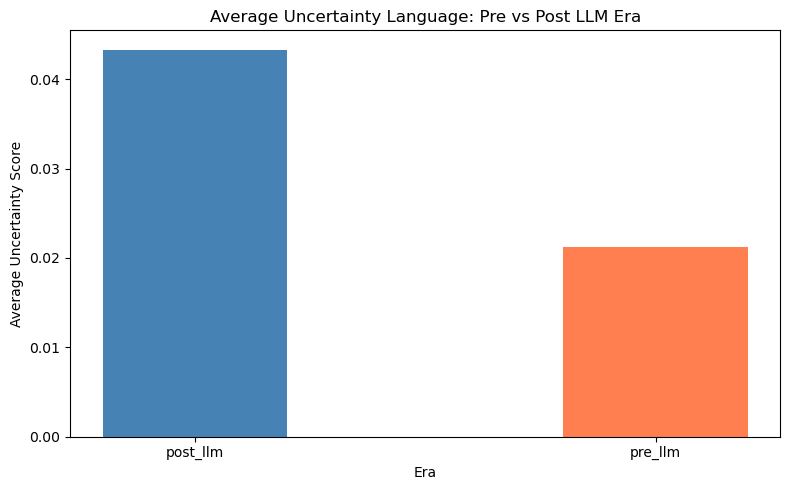

In [7]:
# Define uncertainty/cognitive offloading keywords
uncertainty_words = [
    "should i", "not sure", "don't know", "what do you think",
    "help me", "tell me", "can you", "what should", "i can't decide",
    "confused", "overwhelmed", "just ask", "asked ai", "asked chatgpt"
]

# Count how many uncertainty words appear in each comment
def count_uncertainty(text):
    text = str(text).lower()
    return sum(1 for word in uncertainty_words if word in text)

df_balanced["uncertainty_score"] = df_balanced["text"].apply(count_uncertainty)

# Compare average uncertainty by era
uncertainty_by_era = df_balanced.groupby("era")["uncertainty_score"].mean()
print(uncertainty_by_era)

# Plot it
plt.figure(figsize=(8, 5))
plt.bar(uncertainty_by_era.index, uncertainty_by_era.values,
        color=["steelblue", "coral"], width=0.4)
plt.title("Average Uncertainty Language: Pre vs Post LLM Era")
plt.xlabel("Era")
plt.ylabel("Average Uncertainty Score")
plt.tight_layout()
plt.show()

In [9]:
from scipy import stats

pre = df_balanced[df_balanced["era"] == "pre_llm"]["uncertainty_score"]
post = df_balanced[df_balanced["era"] == "post_llm"]["uncertainty_score"]

t_stat, p_value = stats.ttest_ind(pre, post)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("✓ Result is statistically significant!")
else:
    print("Result is not statistically significant")

T-statistic: -18.6956
P-value: 0.000000
✓ Result is statistically significant!


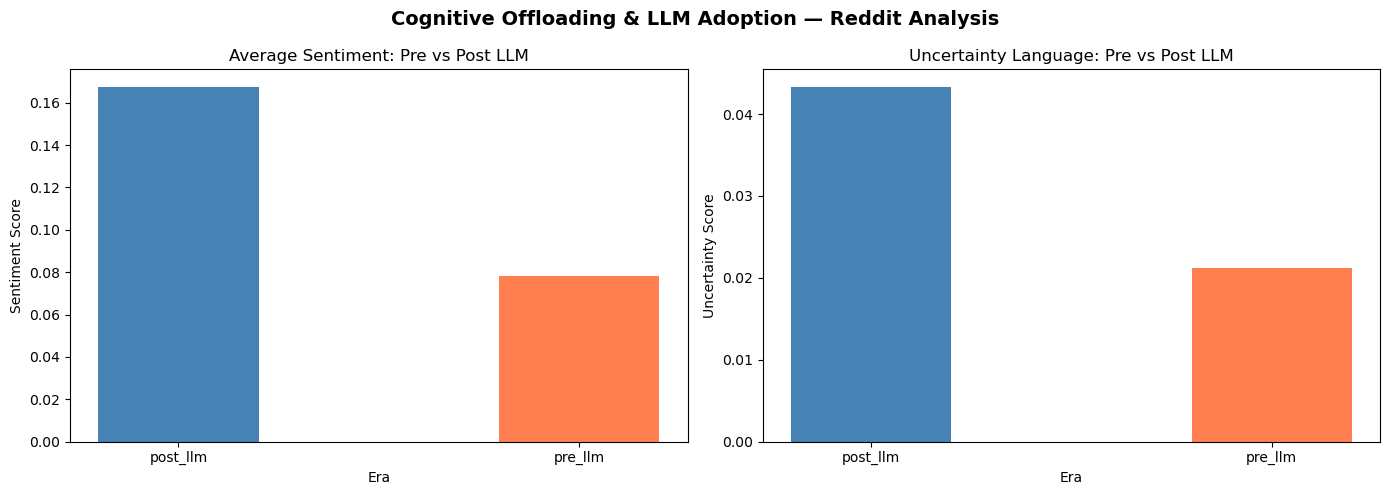

Chart saved!


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 - Sentiment
axes[0].bar(sentiment_by_era.index, sentiment_by_era.values,
            color=["steelblue", "coral"], width=0.4)
axes[0].set_title("Average Sentiment: Pre vs Post LLM")
axes[0].set_ylabel("Sentiment Score")
axes[0].set_xlabel("Era")

# Chart 2 - Uncertainty
axes[1].bar(uncertainty_by_era.index, uncertainty_by_era.values,
            color=["steelblue", "coral"], width=0.4)
axes[1].set_title("Uncertainty Language: Pre vs Post LLM")
axes[1].set_ylabel("Uncertainty Score")
axes[1].set_xlabel("Era")

plt.suptitle("Cognitive Offloading & LLM Adoption — Reddit Analysis", 
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("cognitive_offloading_results.png", dpi=150)
plt.show()

print("Chart saved!")

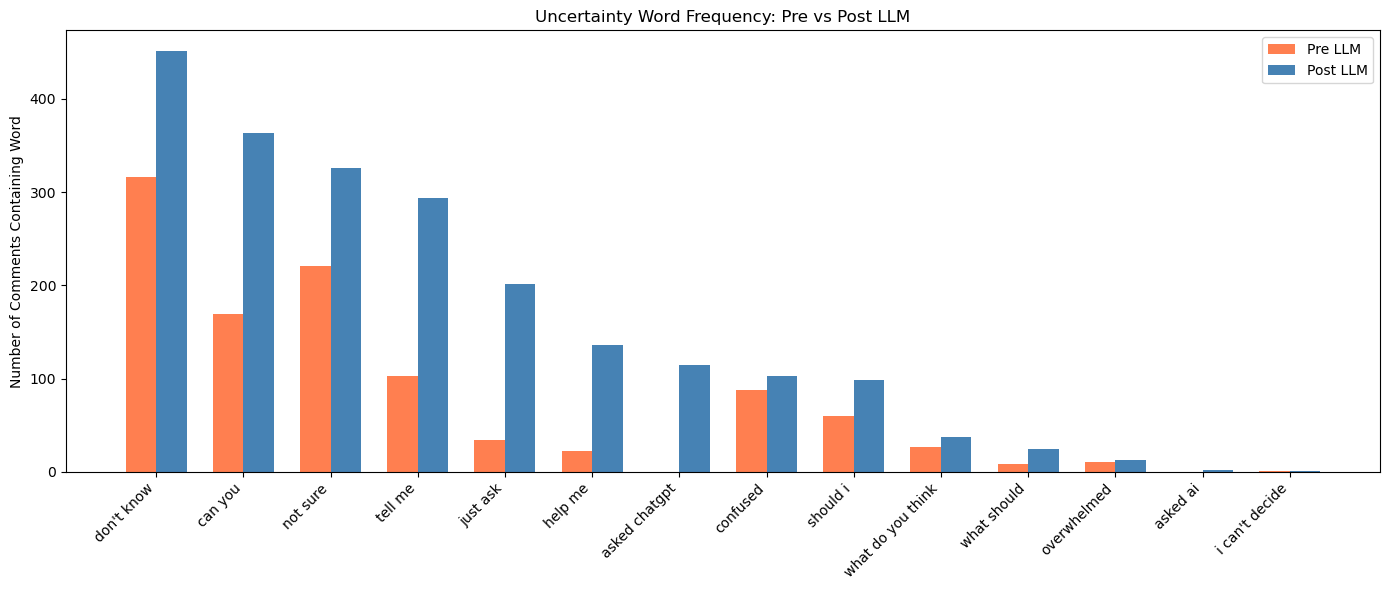

In [11]:
# Count each uncertainty word individually by era
word_data = []

for word in uncertainty_words:
    pre_count = df_balanced[df_balanced["era"] == "pre_llm"]["text"].str.lower().str.contains(word).sum()
    post_count = df_balanced[df_balanced["era"] == "post_llm"]["text"].str.lower().str.contains(word).sum()
    word_data.append({"word": word, "pre_llm": pre_count, "post_llm": post_count})

word_df = pd.DataFrame(word_data).sort_values("post_llm", ascending=False)

# Plot
x = range(len(word_df))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar([i - width/2 for i in x], word_df["pre_llm"], width, label="Pre LLM", color="coral")
ax.bar([i + width/2 for i in x], word_df["post_llm"], width, label="Post LLM", color="steelblue")

ax.set_xticks(list(x))
ax.set_xticklabels(word_df["word"], rotation=45, ha="right")
ax.set_title("Uncertainty Word Frequency: Pre vs Post LLM")
ax.set_ylabel("Number of Comments Containing Word")
ax.legend()
plt.tight_layout()
plt.savefig("word_breakdown.png", dpi=150)
plt.show()

era
post_llm    39.612712
pre_llm     29.070680
Name: word_count, dtype: float64


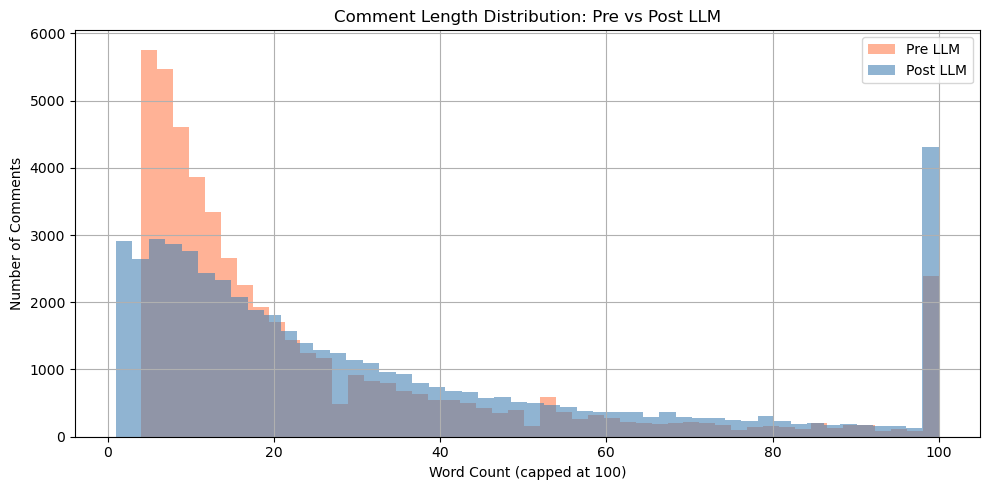

In [12]:
# Calculate comment length in words
df_balanced["word_count"] = df_balanced["text"].apply(
    lambda x: len(str(x).split())
)

# Average word count by era
length_by_era = df_balanced.groupby("era")["word_count"].mean()
print(length_by_era)

# Plot distribution
fig, ax = plt.subplots(figsize=(10, 5))
df_balanced[df_balanced["era"] == "pre_llm"]["word_count"].clip(0, 100).hist(
    bins=50, alpha=0.6, color="coral", label="Pre LLM", ax=ax)
df_balanced[df_balanced["era"] == "post_llm"]["word_count"].clip(0, 100).hist(
    bins=50, alpha=0.6, color="steelblue", label="Post LLM", ax=ax)

ax.set_title("Comment Length Distribution: Pre vs Post LLM")
ax.set_xlabel("Word Count (capped at 100)")
ax.set_ylabel("Number of Comments")
ax.legend()
plt.tight_layout()
plt.savefig("comment_length.png", dpi=150)
plt.show()

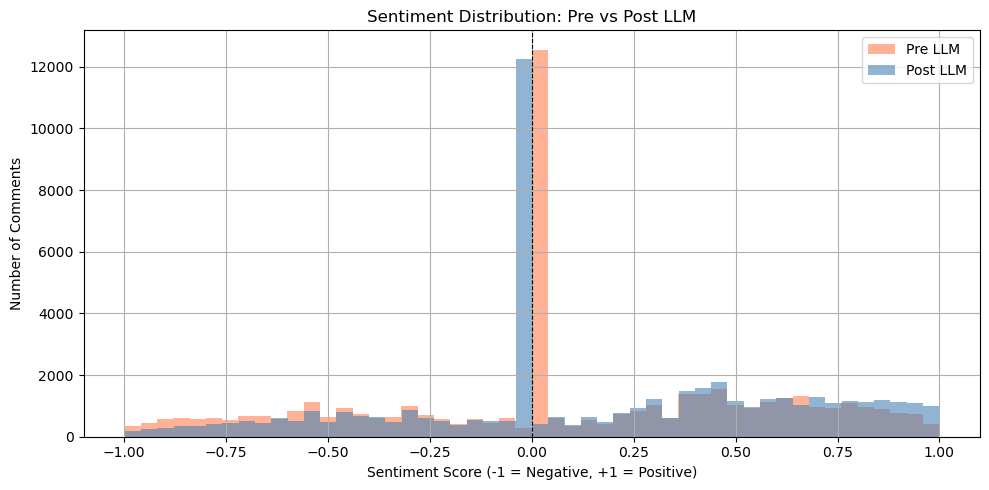

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

df_balanced[df_balanced["era"] == "pre_llm"]["sentiment"].hist(
    bins=50, alpha=0.6, color="coral", label="Pre LLM", ax=ax)
df_balanced[df_balanced["era"] == "post_llm"]["sentiment"].hist(
    bins=50, alpha=0.6, color="steelblue", label="Post LLM", ax=ax)

ax.set_title("Sentiment Distribution: Pre vs Post LLM")
ax.set_xlabel("Sentiment Score (-1 = Negative, +1 = Positive)")
ax.set_ylabel("Number of Comments")
ax.axvline(x=0, color="black", linestyle="--", linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.savefig("sentiment_distribution.png", dpi=150)
plt.show()

era
post_llm    39.134783
pre_llm     39.442000
Name: strong_opinion, dtype: float64


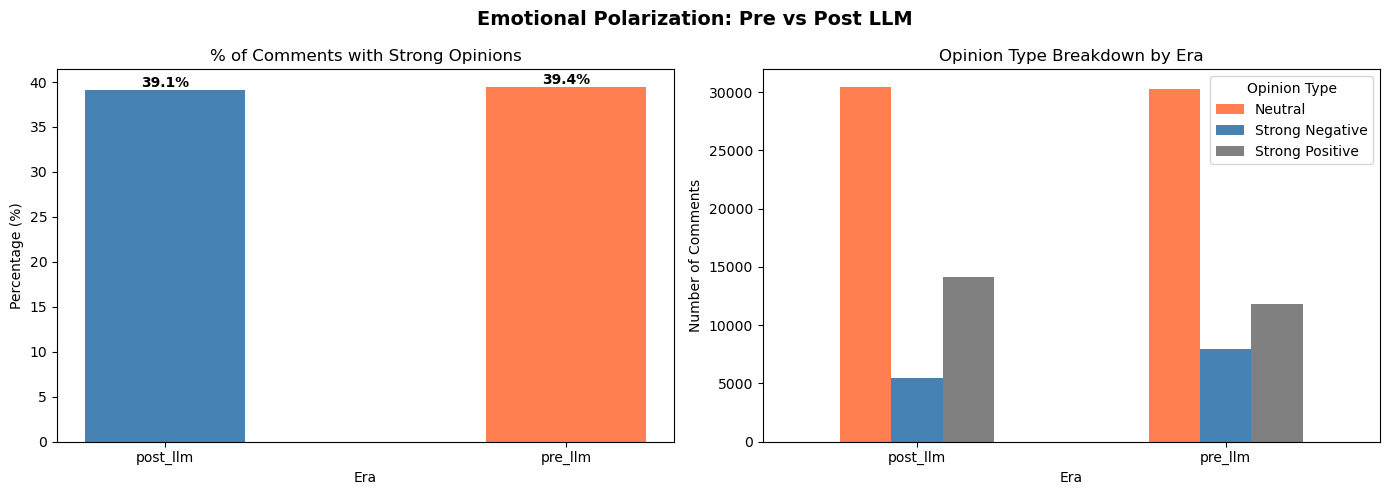

In [14]:
# Define "strong opinion" as sentiment above 0.5 or below -0.5
df_balanced["strong_opinion"] = df_balanced["sentiment"].apply(
    lambda x: 1 if abs(x) >= 0.5 else 0
)

# What % of comments have strong opinions by era
polarization = df_balanced.groupby("era")["strong_opinion"].mean() * 100
print(polarization)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 - % strong opinions
axes[0].bar(polarization.index, polarization.values,
            color=["steelblue", "coral"], width=0.4)
axes[0].set_title("% of Comments with Strong Opinions")
axes[0].set_ylabel("Percentage (%)")
axes[0].set_xlabel("Era")
for i, v in enumerate(polarization.values):
    axes[0].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontweight="bold")

# Chart 2 - breakdown of strong positive vs strong negative
df_balanced["opinion_type"] = df_balanced["sentiment"].apply(
    lambda x: "Strong Positive" if x >= 0.5 
    else ("Strong Negative" if x <= -0.5 else "Neutral")
)

opinion_breakdown = df_balanced.groupby(["era", "opinion_type"]).size().unstack()
opinion_breakdown.plot(kind="bar", ax=axes[1], 
                       color=["coral", "steelblue", "gray"],
                       width=0.5)
axes[1].set_title("Opinion Type Breakdown by Era")
axes[1].set_ylabel("Number of Comments")
axes[1].set_xlabel("Era")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Opinion Type")

plt.suptitle("Emotional Polarization: Pre vs Post LLM", 
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("polarization.png", dpi=150)
plt.show()

In [15]:
# Reload the original AI dataset to check for date columns
df_ai_raw = pd.read_csv("chatgpt-reddit-comments.csv")
print(df_ai_raw.columns.tolist())
print(df_ai_raw.head(3))

['Unnamed: 0', 'comment_id', 'comment_parent_id', 'comment_body', 'subreddit']
  Unnamed: 0 comment_id comment_parent_id  \
0          0    iztdxuh         t3_zj2aeu   
1          1    iztn0q0         t3_zj2aeu   
2          2    izudrph         t3_zj2aeu   

                                        comment_body  subreddit  
0  I've been shocked for days now, I don't need c...  r/ChatGPT  
1   \n\nI am so angry right now. I just wasted my...  r/ChatGPT  
2  chatgpt karma whoring is here folks! just when...  r/ChatGPT  
